# Tutorial: Hierarchical Agent Pattern with **Open Source AgentGrid** SDKs

- Author: Shridhar Kini
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run at root directory of the repo: `jupyter notebook --allow-root --port 9999 --ip=0.0.0.0` 
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace 8_Hierarchical_Pattern.ipynb` 

This walkthrough demonstrates how to build and orchestrate a `Hierarchical agentic company demo` using the **AgentGrid SDKs**. We focus on a **Software Product Lifecycle**, where a CEO initiates a project and a Chief of Staff coordinates with specialized Team Leads (Marketing, Financial, Architecture, Development, Testing) and 12+ sub-agents to build a final report.

## Resource Links
To Know more about the Open Source AgentGrid SDKs, please refer to the [AgentGrid Github](https://github.com/opencyber-space/AgentGr.id) or Resource [AgentGrid SDKs Documentation](https://resources.agentgr.id/) or (https://www.agentgr.id/) 

## Agentic Patterns Link
To know more about the Agentic Patterns, please refer to the [Agentic Patterns](https://www.anthropic.com/engineering/building-effective-agents) And [Video](https://www.youtube.com/watch?v=e2zIr_2JMbE) And [Blog](https://www.mattprd.com/p/the-complete-beginners-guide-to-autonomous-agents)

---

## 1. Agent LLM Interface: `agents_llm`

The `agents_llm` library provides a unified interface for model inference. This allows you to swap models (Qwen, Llama, etc.) without changing your agent's core logic. The models which are hosted in AIOS as blocks or 3rd party models like OpenAI/Gemini/etc also can be accessed via the `agents_llm` library.

---

## 2. Orchestration & Communication: `agents_sdk`

The `agents_sdk` framework handles the "lifecycle" and "social" aspects of an agent. It provides core data structures like `AgentTask` and `AgentResult`, and a `Context` object for peer-to-peer (`p2p_manager`), delegated (`delegator`), or direct (`direct`) communication.

---

## 3. Case Study: Hierarchical Software Company Demo

The **Hierarchical Agent Pattern** mirrors a real-world enterprise structure. It handles complexity by delegating tasks down a chain of command and routing technical artifacts between specialized departments.

### Project Lifecycle Pipeline (7 Stages):
1. **Initiate**: The `CEO Agent` refines a user project idea into a structured `ProblemStatement`.
2. **Broadcast**: The `Chief of Staff (CoS)` identifies necessary teams and requests `BudgetEstimates`.
3. **Approve**: The `Financial Team Lead` coordinates with the `Accountant`, `Controller`, and `Strategist` to evaluate the budget, applying 20% cuts if disapproved. 
4. **Execute**: Marketing and Architecture teams start parallel work immediately upon approval.
5. **Route**: Upon design completion, the CoS routes the `Architecture Blueprint` to the Developers.
6. **Validate**: Development output is routed to Testing for verification and bug reporting.
7. **Finalize**: The CoS summarizes all outcomes into a `ProjectOutcome` for the CEO's review.

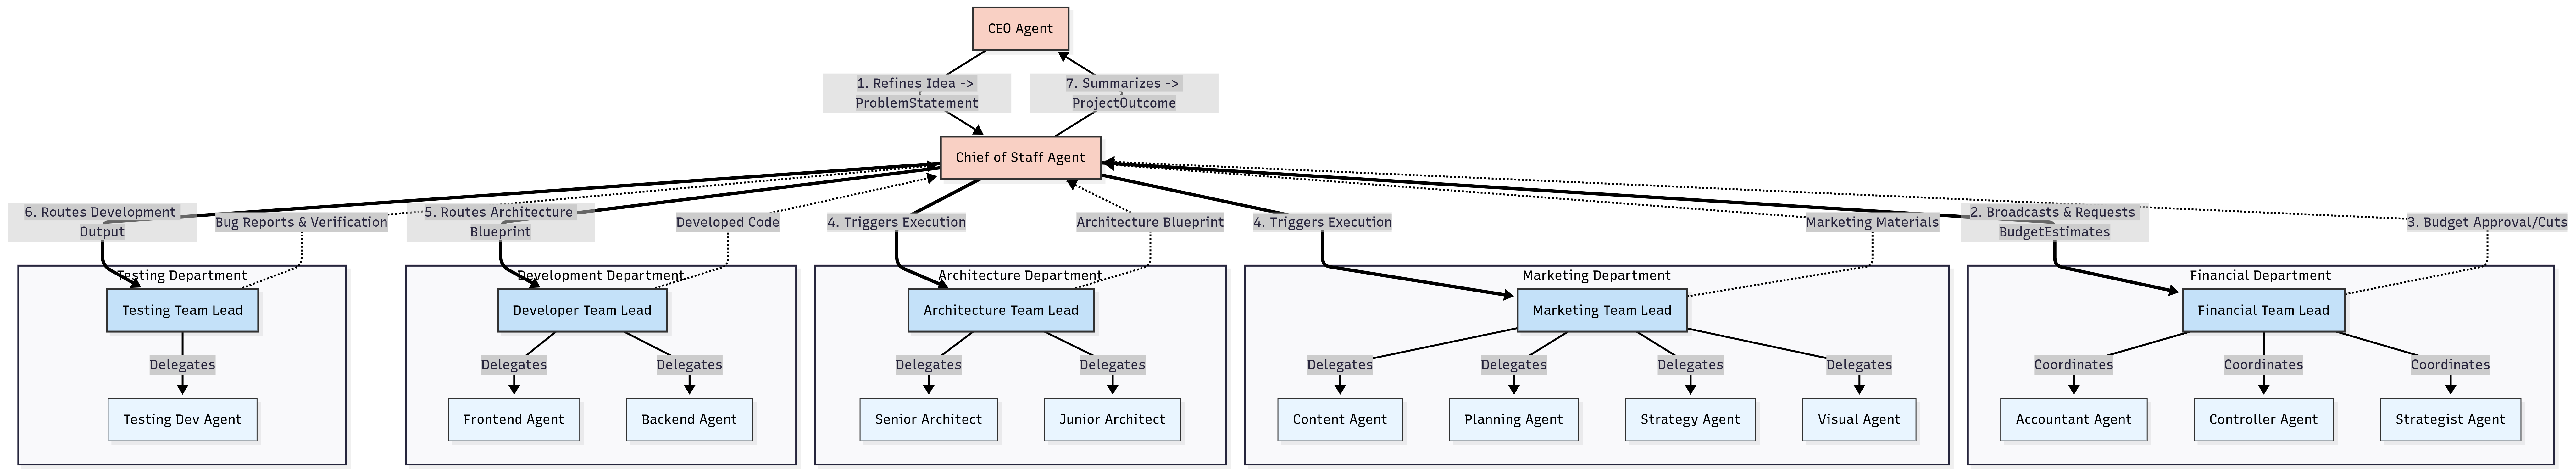

### Agent Roles & Source Files

| Department | Agent Role | Source File |
| :--- | :--- | :--- |
| **Leadership** | CEO Agent | [`agent_ceo.py`](../../agent_codes/hierarchical_agents/agent_ceo.py) |
| | Chief of Staff | [`agent_cos.py`](../../agent_codes/hierarchical_agents/agent_cos.py) |
| **Marketing** | Team Lead | [`agent_marketing_team_lead.py`](../../agent_codes/hierarchical_agents/agent_marketing_team_lead.py) |
| | Content Agent | [`agent_marketing_content.py`](../../agent_codes/hierarchical_agents/agent_marketing_content.py) |
| | Planning Agent | [`agent_marketing_planning.py`](../../agent_codes/hierarchical_agents/agent_marketing_planning.py) |
| | Strategy Agent | [`agent_marketing_strategy.py`](../../agent_codes/hierarchical_agents/agent_marketing_strategy.py) |
| | Visual Agent | [`agent_marketing_visual.py`](../../agent_codes/hierarchical_agents/agent_marketing_visual.py) |
| **Financial** | Team Lead | [`agent_financial_team_lead.py`](../../agent_codes/hierarchical_agents/agent_financial_team_lead.py) |
| | Controller Agent | [`agent_financial_controller.py`](../../agent_codes/hierarchical_agents/agent_financial_controller.py) |
| | Strategist Agent | [`agent_financial_strategist.py`](../../agent_codes/hierarchical_agents/agent_financial_strategist.py) |
| | Accountant Agent | [`agent_financial_accountant.py`](../../agent_codes/hierarchical_agents/agent_financial_accountant.py) |
| **Architecture** | Team Lead | [`agent_arch_design_team_lead.py`](../../agent_codes/hierarchical_agents/agent_arch_design_team_lead.py) |
| | Senior Architect | [`agent_arch_senior.py`](../../agent_codes/hierarchical_agents/agent_arch_senior.py) |
| | Junior Architect | [`agent_arch_junior.py`](../../agent_codes/hierarchical_agents/agent_arch_junior.py) |
| **Developer** | Team Lead | [`agent_developer_team_lead.py`](../../agent_codes/hierarchical_agents/agent_developer_team_lead.py) |
| | Frontend Agent | [`agent_dev_frontend.py`](../../agent_codes/hierarchical_agents/agent_dev_frontend.py) |
| | Backend Agent | [`agent_dev_backend.py`](../../agent_codes/hierarchical_agents/agent_dev_backend.py) |
| **Testing** | Team Lead | [`agent_testing_team_lead.py`](../../agent_codes/hierarchical_agents/agent_testing_team_lead.py) |
| | Testing Dev | [`agent_testing_dev.py`](../../agent_codes/hierarchical_agents/agent_testing_dev.py) |

---

## 4. Execution Pipeline

1. **Agent Registration**: Register all company agents in the cluster.
   - Script: [register-agents.sh](../../agents_registration/8_Hierarchical_SoftwareCompany_agents/register-agents.sh)
2. **Deployment**: Spin up containers for the multi-stage company workflow.
   - Script: [deploy-agents.sh](../../agents_registration/8_Hierarchical_SoftwareCompany_agents/deploy-agents.sh)
3. **Triggering the Flow**: Send the initial "go signal" idea to the **CEO**.
   - Script: [inference_request.sh](../../agents_registration/8_Hierarchical_SoftwareCompany_agents/inference_request.sh)
4. **All in One**: Run [all.bash](../../agents_registration/8_Hierarchical_SoftwareCompany_agents/all.bash) to register and deploy everything.

#### Run all.bash to setup the Hierarchical Company Flow

In [ ]:
%%bash
cd ../../agents_registration/8_Hierarchical_SoftwareCompany_agents
bash all.bash

#### Run Streamlit app for watching the agents in action

In [ ]:
%%bash --bg --proc hierarchical_company_process
cd ../../agents_registration/8_Hierarchical_SoftwareCompany_agents
source ../../agent_codes/venv/bin/activate
bash run_streamlit_app.bash

#### Check for pods in agents namespace

In [3]:
%%bash
kubectl get pods -n agents

2026/03/10 09:50:19 Starlark failed to allocate 4GB address space: cannot allocate memory. Integer performance may suffer.


NAME                                                           READY   STATUS    RESTARTS   AGE
executor-company-arch-design-team-lead-7c9d56cdf9-9wq48        3/3     Running   0          20h
executor-company-arch-junior-agent-5bfd6f95d7-s299s            3/3     Running   0          20h
executor-company-arch-senior-agent-5586cfb95d-5562f            3/3     Running   0          20h
executor-company-ceo-agent-774c9f8cb4-jc5pl                    3/3     Running   0          20h
executor-company-chief-of-staff-agent-785fb796f-rnjjv          3/3     Running   0          20h
executor-company-dev-backend-agent-6bb56dff9f-ws779            3/3     Running   0          20h
executor-company-dev-frontend-agent-686c96d65c-s7pqs           3/3     Running   0          20h
executor-company-developer-team-lead-bf797864-gbks6            3/3     Running   0          20h
executor-company-financial-accountant-agent-8745999c-wfd89     3/3     Running   0          20h
executor-company-financial-controller-ag

#### Trigger the Start Agent (CEO Agent)

In [2]:
%%bash
cd ../../agents_registration/8_Hierarchical_SoftwareCompany_agents
bash inference_request.sh

--- Request 1: Task Management Dashboard ---
Using session_id: sess-taskmgr-06192
INPUT 1:
Develop a Task Management Dashboard (Kanban Style). 

Frontend: A dashboard featuring a task board with columns for To-Do, In Progress, and Done. Include forms for creating new projects and detailed task views.
Backend: APIs to support CRUD operations for projects and tasks, user authentication, and persistent data storage.
--------------------------------------------------
OUTPUT 1:
{"project_outcome": {"status": "completed", "teams": [{"team_name": "Arch & Design Team", "deliverables": ["Architectural Blueprint", "System Design Documentation", "Implementation of Task Management Dashboard"], "status": "success", "blueprint": "Modular System Architecture:\n\n1. Frontend: React with components for task board, project creation, and detailed task views.\n2. Backend: Node.js with Express, supporting RESTful APIs for CRUD operations, user authentication via OAuth 2.0, and secure token validation.\n3. 

## Conclusion
The Hierarchical pattern is ideal for complex business processes that require multi-round coordination, financial oversight, and sequential task dependencies. By mimicking a corporate structure, you can build scalable multi-agent systems that handle end-to-end product development workflows.